# Sales Performance Analysis

## Setup

In [25]:
import os, warnings
warnings.filterwarnings('ignore')

from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import DoubleType, IntegerType

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.stat import Correlation

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120})

print("imports ok")

imports ok


In [26]:
# 2 workers, 1 driver — each gets 2 GB
spark = (
    SparkSession.builder
    .appName("SalesAnalysis")
    .master("local[3]")
    .config("spark.driver.memory", "2g")
    .config("spark.executor.memory", "2g")
    .config("spark.executor.cores", "1")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

sc = spark.sparkContext
print(f"Spark {spark.version}")
print(f"Driver memory : {sc._conf.get('spark.driver.memory')}")
print(f"Executor memory: {sc._conf.get('spark.executor.memory')}")
print(f"Cores : {sc.defaultParallelism}")

Spark 4.1.1
Driver memory : 2g
Executor memory: 2g
Cores : 3


## Load Data

In [27]:
BASE = "/home/saag/Documents/BigDataCW/cleaned_dataset"

def read_csv(name):
    """Read partitioned CSV directory."""
    return spark.read.csv(os.path.join(BASE, name), header=True, inferSchema=True)

orders      = read_csv("orders_cleaned.csv")
order_items = read_csv("order_items_cleaned.csv")
products    = read_csv("products_cleaned.csv")
customers   = read_csv("customers_cleaned.csv")
date_dim    = read_csv("date_dim_cleaned.csv")

for name, df in [("orders", orders), ("order_items", order_items),
                 ("products", products), ("customers", customers), ("date_dim", date_dim)]:
    print(f"{name:15s}  rows={df.count():>7,}  cols={len(df.columns)}")

orders           rows=400,000  cols=9
order_items      rows=919,204  cols=6
products         rows=  5,000  cols=8
customers        rows=121,200  cols=9
date_dim         rows=  2,557  cols=10


In [28]:
# join items to orders and products
fact = (
    order_items
    .join(orders,   on="order_id",   how="inner")
    .join(products, on="product_id", how="inner")
    .withColumn("revenue", F.col("line_total"))
    .withColumn("profit",  F.col("line_total") * (1 - F.col("discount_pct")) * 0.30)
    .withColumn("order_year",  F.year("order_date"))
    .withColumn("order_month", F.month("order_date"))
)

# only delivered orders count as confirmed revenue
delivered = fact.filter(F.col("order_status") == "Delivered")

print(f"all rows      : {fact.count():,}")
print(f"delivered rows: {delivered.count():,}")

all rows      : 918,954


delivered rows: 552,629


## KPI Overview

In [29]:
kpi = delivered.agg(
    F.round(F.sum("revenue"), 2).alias("total_revenue"),
    F.round(F.sum("profit"),  2).alias("total_profit"),
    F.countDistinct("order_id").alias("total_orders"),
    F.round(F.avg("revenue"), 2).alias("avg_order_value"),
).collect()[0]

total_revenue   = kpi["total_revenue"]
total_profit    = kpi["total_profit"]
total_orders    = kpi["total_orders"]
avg_order_value = kpi["avg_order_value"]

print(f"Revenue   : NPR {total_revenue:>15,.2f}")
print(f"Profit    : NPR {total_profit:>15,.2f}")
print(f"Orders    :     {total_orders:>15,}")
print(f"Avg Order : NPR {avg_order_value:>15,.2f}")

Revenue   : NPR 12,411,411,059.32
Profit    : NPR 3,281,674,597.07
Orders    :             240,352
Avg Order : NPR       22,458.85


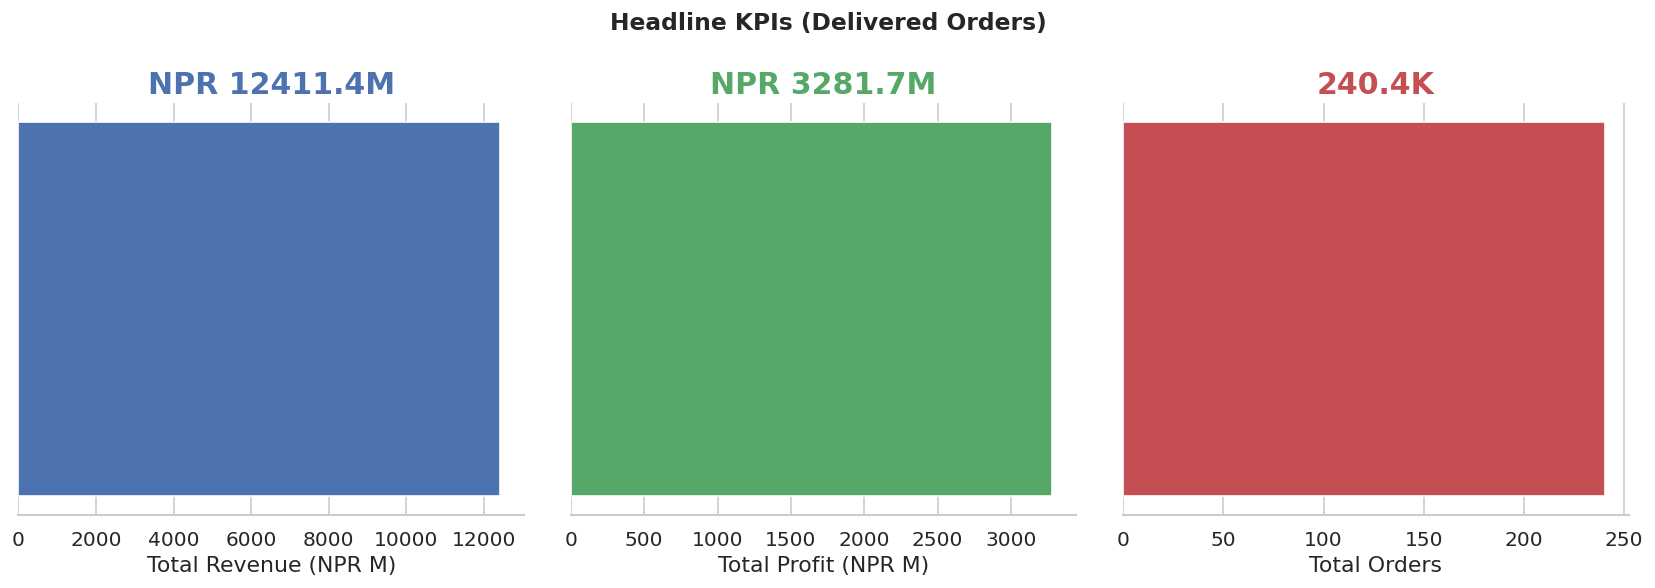

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Headline KPIs (Delivered Orders)", fontsize=14, fontweight="bold")

kpi_data = [
    ("Total Revenue (NPR M)", total_revenue / 1e6, "NPR {:.1f}M", "#4C72B0"),
    ("Total Profit (NPR M)",  total_profit  / 1e6, "NPR {:.1f}M", "#55A868"),
    ("Total Orders",          total_orders  / 1e3, "{:.1f}K",     "#C44E52"),
]

for ax, (label, value, fmt, color) in zip(axes, kpi_data):
    ax.barh([0], [value], color=color, height=0.4)
    ax.set_yticks([])
    ax.set_xlabel(label)
    ax.set_title(fmt.format(value), fontsize=18, fontweight="bold", color=color)
    ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()

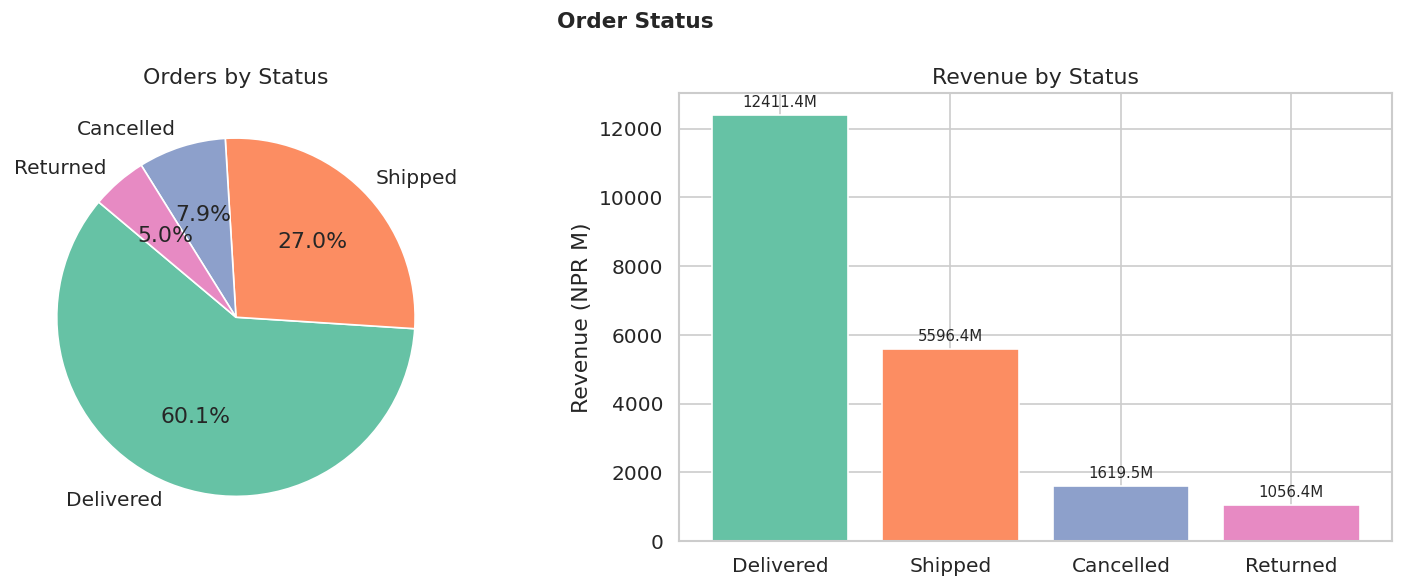

In [31]:
status_df = (
    fact
    .groupBy("order_status")
    .agg(
        F.countDistinct("order_id").alias("orders"),
        F.round(F.sum("revenue"), 2).alias("revenue"),
    )
    .orderBy(F.desc("revenue"))
    .toPandas()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Order Status", fontsize=13, fontweight="bold")

ax1.pie(status_df["orders"], labels=status_df["order_status"],
        autopct="%1.1f%%", startangle=140,
        colors=sns.color_palette("Set2", len(status_df)))
ax1.set_title("Orders by Status")

bars = ax2.bar(status_df["order_status"], status_df["revenue"] / 1e6,
               color=sns.color_palette("Set2", len(status_df)))
ax2.set_ylabel("Revenue (NPR M)")
ax2.set_title("Revenue by Status")
ax2.bar_label(bars, fmt="%.1fM", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

## Sales by Category

In [32]:
cat_df = (
    delivered
    .groupBy("category")
    .agg(
        F.round(F.sum("revenue"), 2).alias("revenue"),
        F.round(F.sum("profit"),  2).alias("profit"),
        F.countDistinct("order_id").alias("orders"),
        F.round(F.avg("discount_pct") * 100, 1).alias("avg_discount_pct"),
    )
    .orderBy(F.desc("revenue"))
    .toPandas()
)

cat_df

,category,revenue,profit,orders,avg_discount_pct
0,Electronics,7.690364e+09,2.033885e+09,47866,12.5
1,Home & Garden,2.064646e+09,5.456777e+08,28889,12.5
2,Sports & Outdoors,8.151213e+08,2.155647e+08,19161,12.4
3,Clothing,6.786879e+08,1.792437e+08,43391,12.5
4,Beauty & Health,4.234809e+08,1.119233e+08,31461,12.5
5,Toys & Games,3.033887e+08,8.020155e+07,22574,12.5
6,Food & Grocery,2.577986e+08,6.814435e+07,31152,12.5
7,Books,1.779244e+08,4.703397e+07,24056,12.5


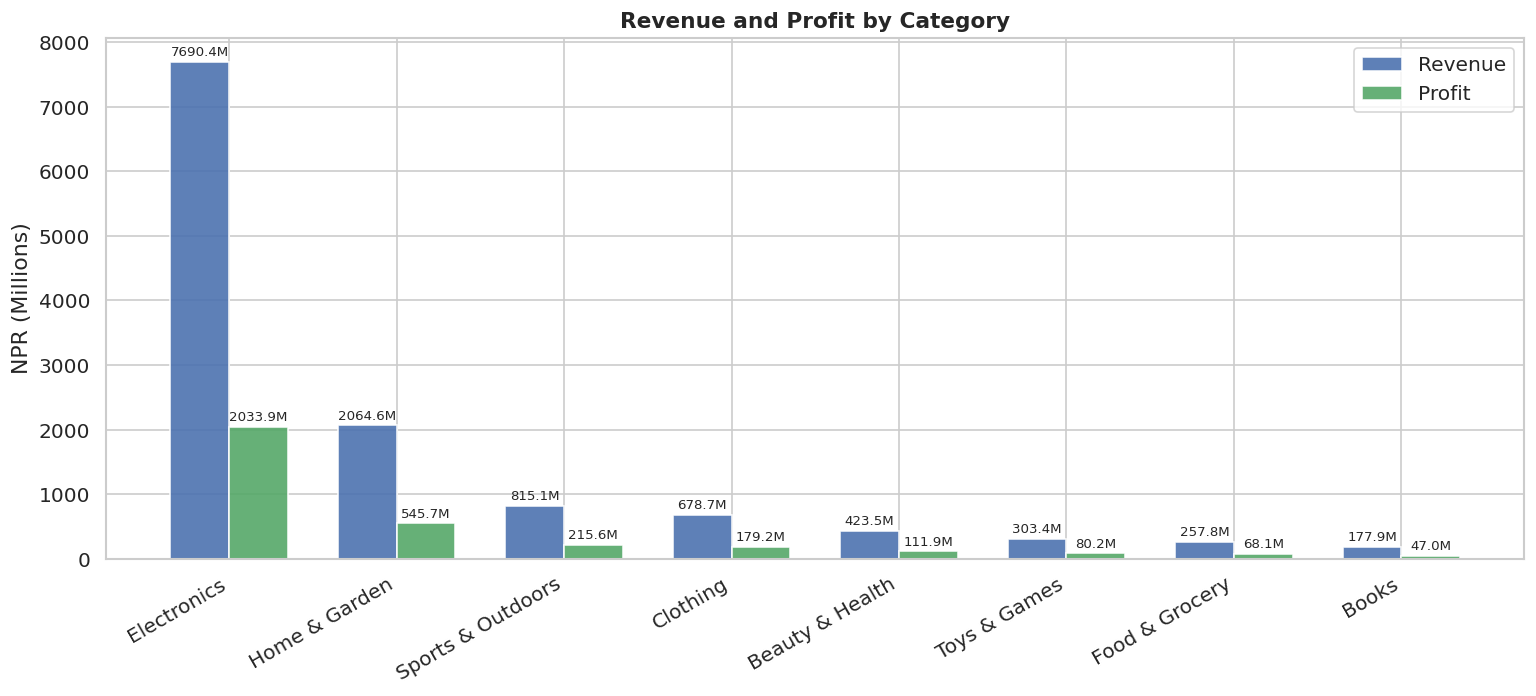

In [33]:
x = np.arange(len(cat_df))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars_rev = ax.bar(x - width/2, cat_df["revenue"] / 1e6, width, label="Revenue", color="#4C72B0", alpha=0.9)
bars_pro = ax.bar(x + width/2, cat_df["profit"]  / 1e6, width, label="Profit",  color="#55A868", alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(cat_df["category"], rotation=30, ha="right")
ax.set_ylabel("NPR (Millions)")
ax.set_title("Revenue and Profit by Category", fontsize=13, fontweight="bold")
ax.legend()
ax.bar_label(bars_rev, fmt="%.1fM", padding=2, fontsize=8)
ax.bar_label(bars_pro, fmt="%.1fM", padding=2, fontsize=8)

plt.tight_layout()
plt.show()

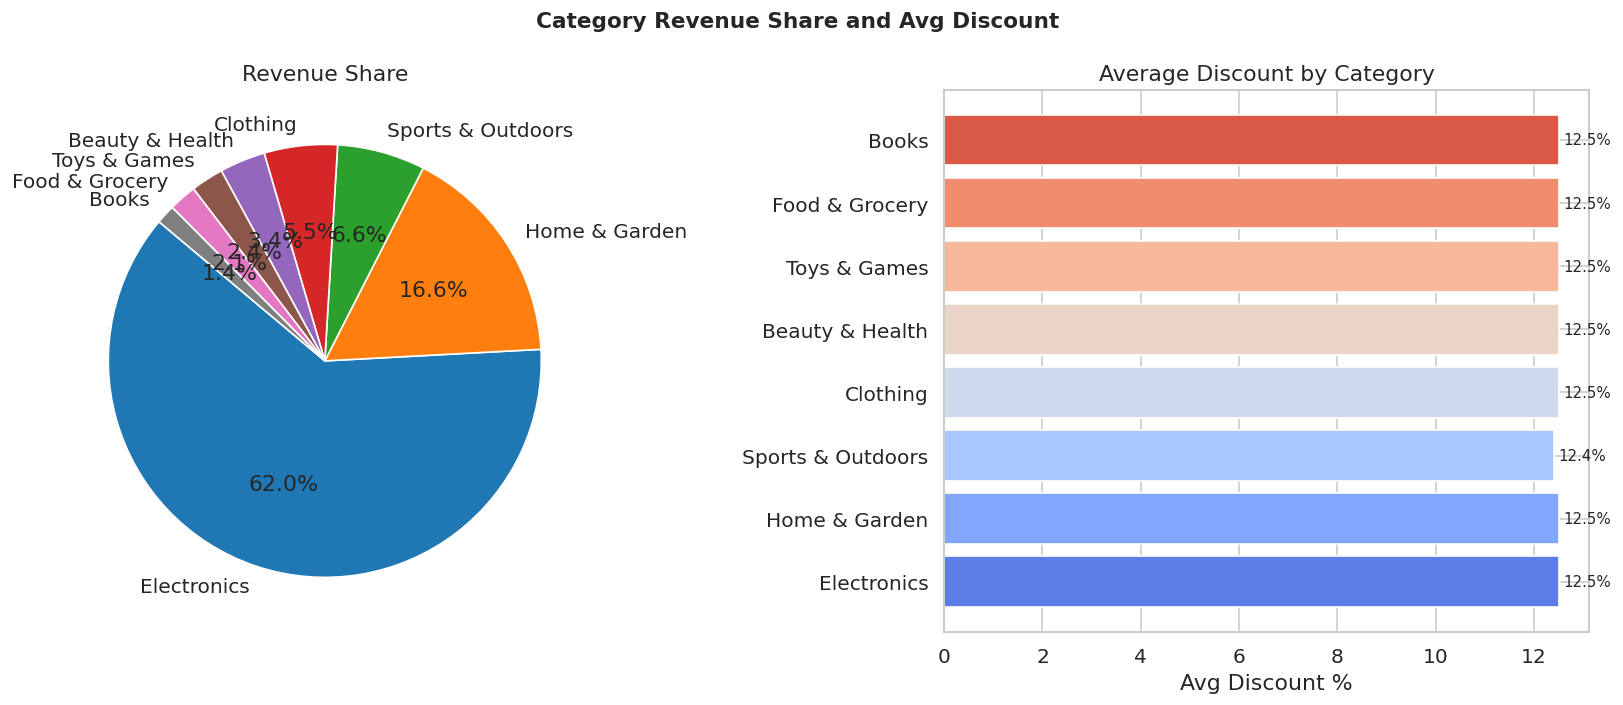

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Category Revenue Share and Avg Discount", fontsize=13, fontweight="bold")

ax1.pie(cat_df["revenue"], labels=cat_df["category"],
        autopct="%1.1f%%", startangle=140,
        colors=sns.color_palette("tab10", len(cat_df)))
ax1.set_title("Revenue Share")

bars = ax2.barh(cat_df["category"], cat_df["avg_discount_pct"],
                color=sns.color_palette("coolwarm", len(cat_df)))
ax2.set_xlabel("Avg Discount %")
ax2.set_title("Average Discount by Category")
ax2.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

## Sales by Region

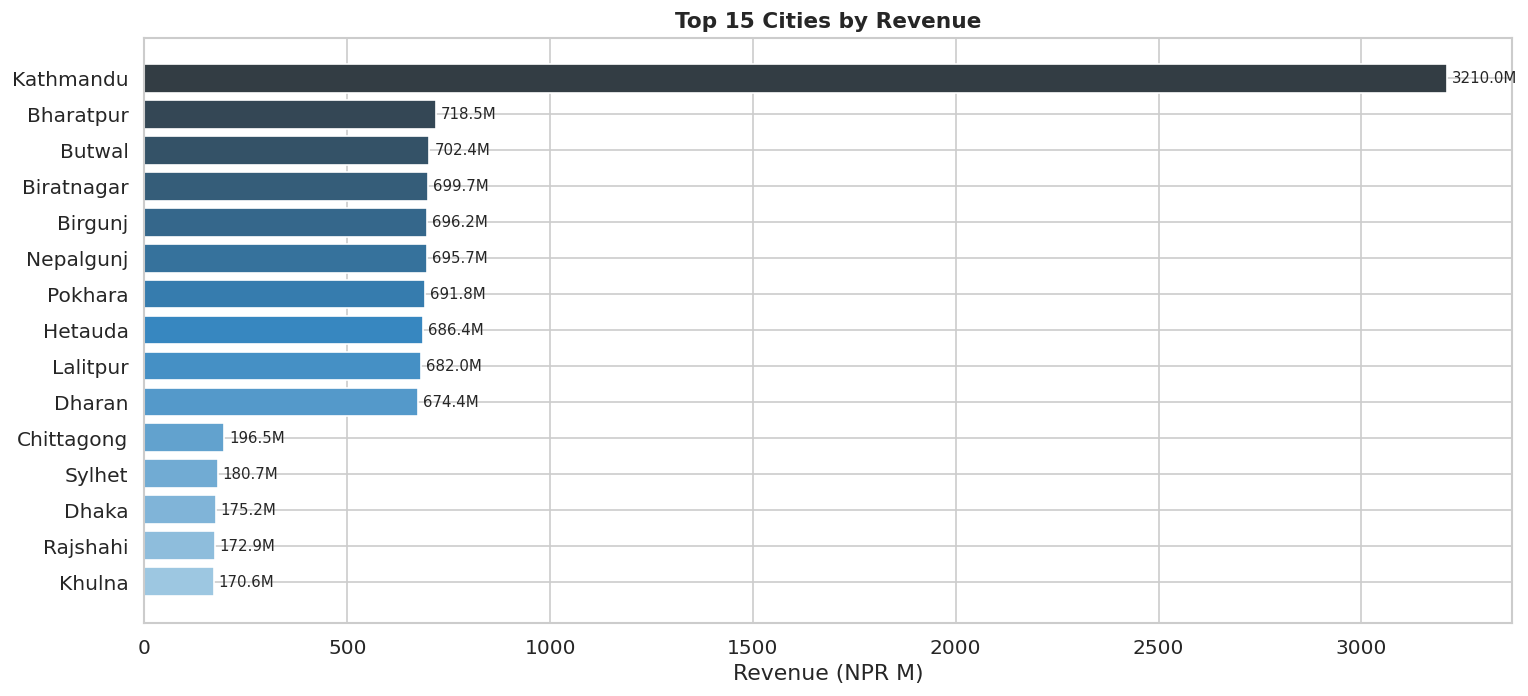

In [35]:
city_df = (
    delivered
    .groupBy("shipping_city")
    .agg(
        F.round(F.sum("revenue"), 2).alias("revenue"),
        F.round(F.sum("profit"),  2).alias("profit"),
        F.countDistinct("order_id").alias("orders"),
    )
    .orderBy(F.desc("revenue"))
    .limit(15)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(city_df["shipping_city"][::-1], city_df["revenue"][::-1] / 1e6,
               color=sns.color_palette("Blues_d", len(city_df)))
ax.set_xlabel("Revenue (NPR M)")
ax.set_title("Top 15 Cities by Revenue", fontsize=13, fontweight="bold")
ax.bar_label(bars, fmt="%.1fM", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

## Sales Over Time

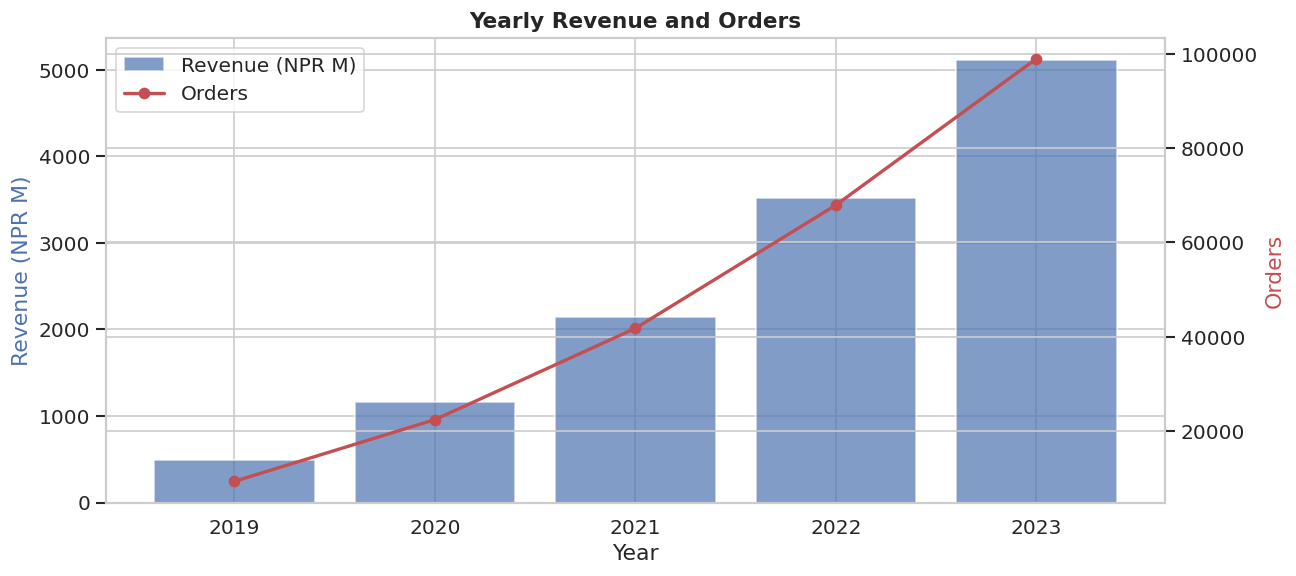

In [36]:
year_df = (
    delivered
    .groupBy("order_year")
    .agg(
        F.round(F.sum("revenue"), 2).alias("revenue"),
        F.countDistinct("order_id").alias("orders"),
    )
    .orderBy("order_year")
    .toPandas()
)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.bar(year_df["order_year"], year_df["revenue"] / 1e6, color="#4C72B0", alpha=0.7, label="Revenue (NPR M)")
ax2.plot(year_df["order_year"], year_df["orders"], color="#C44E52", marker="o", linewidth=2, label="Orders")

ax1.set_xlabel("Year")
ax1.set_ylabel("Revenue (NPR M)", color="#4C72B0")
ax2.set_ylabel("Orders",          color="#C44E52")
ax1.set_title("Yearly Revenue and Orders", fontsize=13, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

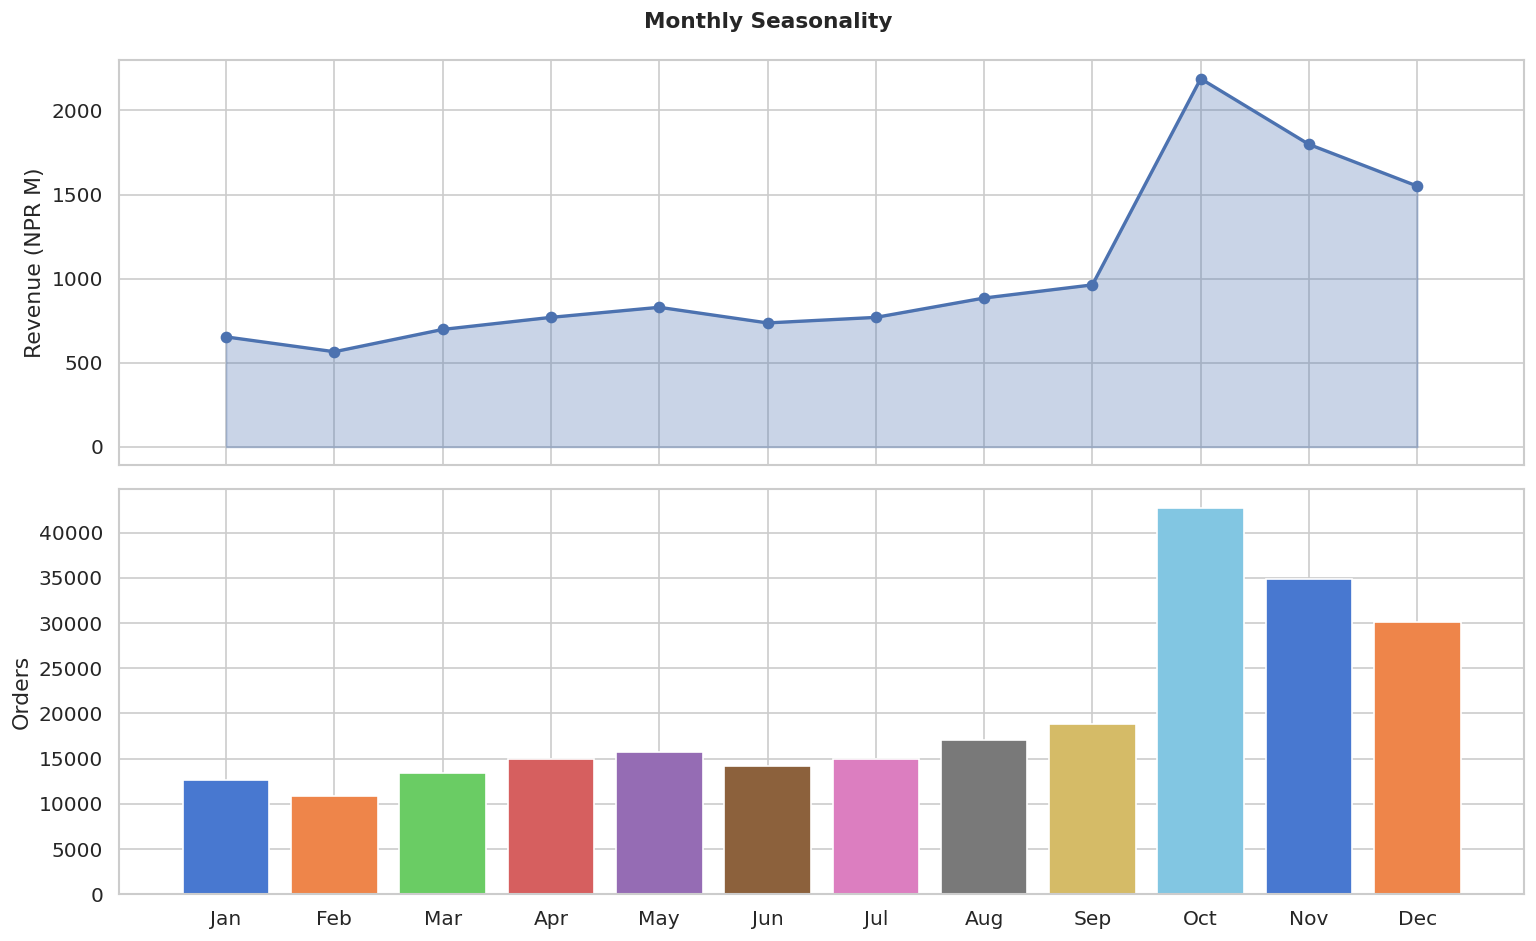

In [37]:
MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

month_df = (
    delivered
    .groupBy("order_month")
    .agg(
        F.round(F.sum("revenue"), 2).alias("revenue"),
        F.countDistinct("order_id").alias("orders"),
    )
    .orderBy("order_month")
    .toPandas()
)
month_df["month_name"] = month_df["order_month"].apply(lambda m: MONTH_NAMES[m-1])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle("Monthly Seasonality", fontsize=13, fontweight="bold")

ax1.fill_between(month_df["month_name"], month_df["revenue"] / 1e6, alpha=0.3, color="#4C72B0")
ax1.plot(month_df["month_name"], month_df["revenue"] / 1e6, marker="o", color="#4C72B0", linewidth=2)
ax1.set_ylabel("Revenue (NPR M)")

ax2.bar(month_df["month_name"], month_df["orders"], color=sns.color_palette("muted", 12))
ax2.set_ylabel("Orders")

plt.tight_layout()
plt.show()

## Top and Low Performing Products

In [38]:
prod_df = (
    delivered
    .groupBy("product_id", "product_name", "category", "subcategory")
    .agg(
        F.round(F.sum("revenue"), 2).alias("revenue"),
        F.round(F.sum("profit"),  2).alias("profit"),
        F.sum("quantity").alias("units_sold"),
        F.countDistinct("order_id").alias("orders"),
    )
    .orderBy(F.desc("revenue"))
    .toPandas()
)

top10 = prod_df.head(10)
bot10 = prod_df.tail(10)

print(f"products with sales: {len(prod_df):,}")
top10[["product_name", "category", "revenue", "units_sold"]]

products with sales: 4,781


,product_name,category,revenue,units_sold
0,Phone Grip Stand Prime,Electronics,29042602.23,680
1,USB-C Hub Adapter Prime,Electronics,28968547.77,664
2,USB Flash Drive 64GB XL,Electronics,28200517.88,667
3,Laptop Cooling Pad Plus,Electronics,27359382.05,648
4,Phone Audio Adapter Ultra,Electronics,27097816.21,628
5,Portable Speaker Mini Lite,Electronics,26738346.44,616
6,Screen Protector HD 2023,Electronics,26615054.37,623
7,Laptop Stand Ergonomic Neo,Electronics,26431967.97,620
8,Microphone USB Studio Air,Electronics,26332731.30,623
9,Noise Cancelling Headset Pro,Electronics,26250789.68,597


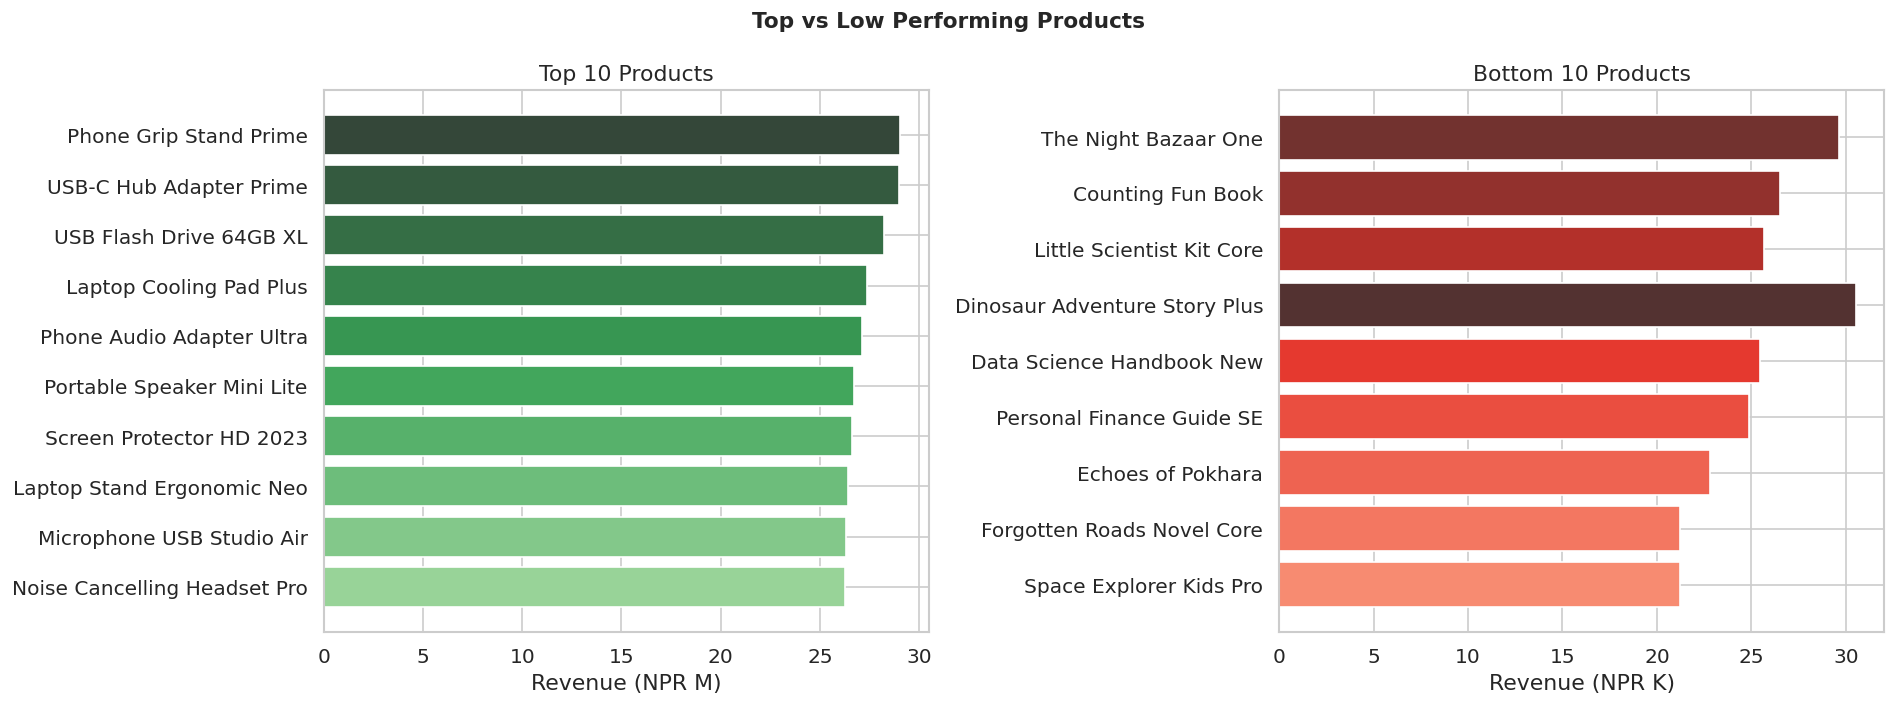

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Top vs Low Performing Products", fontsize=13, fontweight="bold")

top10_labels = [n[:30]+"..." if len(n) > 30 else n for n in top10["product_name"]]
bot10_labels = [n[:30]+"..." if len(n) > 30 else n for n in bot10["product_name"]]

ax1.barh(top10_labels[::-1], top10["revenue"][::-1] / 1e6,
         color=sns.color_palette("Greens_d", 10))
ax1.set_xlabel("Revenue (NPR M)")
ax1.set_title("Top 10 Products")

ax2.barh(bot10_labels[::-1], bot10["revenue"][::-1] / 1e3,
         color=sns.color_palette("Reds_d", 10))
ax2.set_xlabel("Revenue (NPR K)")
ax2.set_title("Bottom 10 Products")

plt.tight_layout()
plt.show()

1172 products make up 80% of revenue (out of 4781)


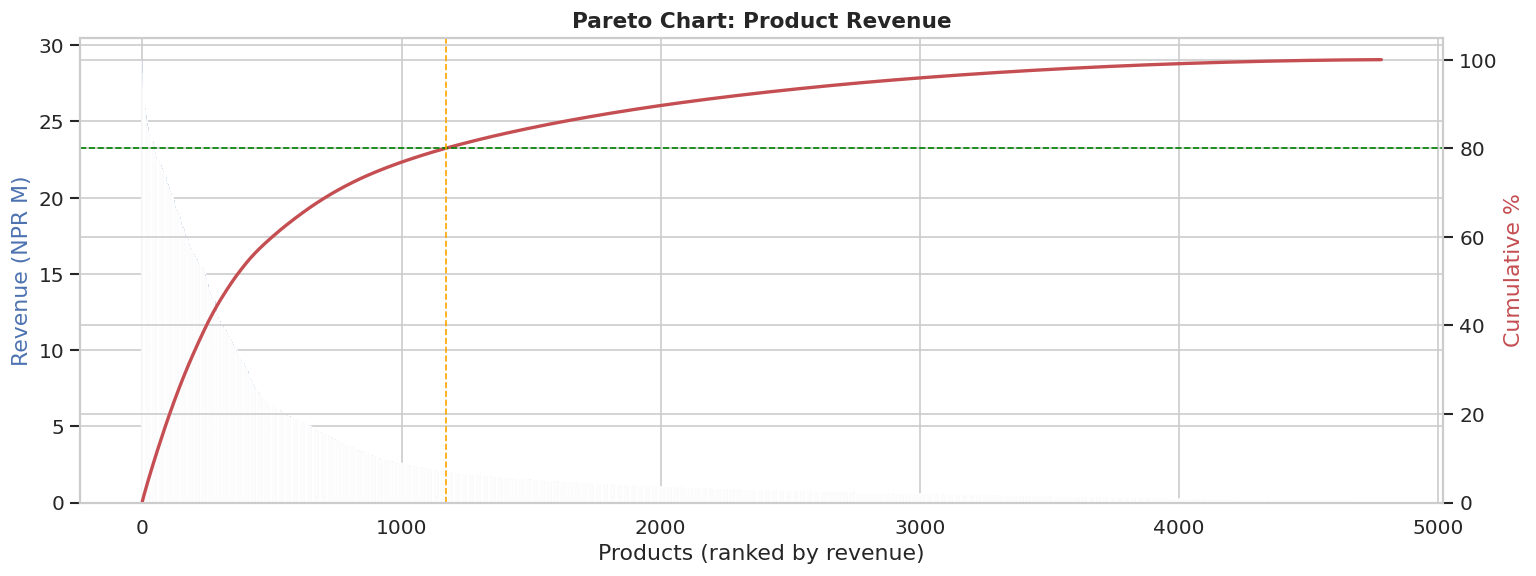

In [40]:
# pareto: how many products cover 80% of revenue
prod_df_sorted = prod_df.sort_values("revenue", ascending=False).reset_index(drop=True)
prod_df_sorted["cum_pct"] = prod_df_sorted["revenue"].cumsum() / prod_df_sorted["revenue"].sum() * 100

cutoff_80 = (prod_df_sorted["cum_pct"] <= 80).sum()
print(f"{cutoff_80} products make up 80% of revenue (out of {len(prod_df_sorted)})")

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.bar(prod_df_sorted.index, prod_df_sorted["revenue"] / 1e6, color="#4C72B0", alpha=0.6)
ax2.plot(prod_df_sorted.index, prod_df_sorted["cum_pct"], color="#C44E52", linewidth=2)
ax2.axhline(80, color="green", linestyle="--", linewidth=1)
ax2.axvline(cutoff_80, color="orange", linestyle="--", linewidth=1)

ax1.set_xlabel("Products (ranked by revenue)")
ax1.set_ylabel("Revenue (NPR M)", color="#4C72B0")
ax2.set_ylabel("Cumulative %",    color="#C44E52")
ax2.set_ylim(0, 105)
ax1.set_title("Pareto Chart: Product Revenue", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

---
<a id="section-8"></a>
## Section 8 — Key Takeaways

> Summary of the most important findings from this analysis.

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **Revenue & profit are concentrated in a few categories** | Focus marketing spend on top categories; investigate whether low-revenue ones are worth maintaining |
| 2 | **Top 15 cities account for most orders** | Targeted fulfilment centres / faster delivery SLAs in top cities would reduce shipping costs |
| 3 | **Seasonal peaks exist** — typically mid-year & year-end | Plan inventory & promotional campaigns 4–6 weeks ahead of peak months |
| 4 | **Pareto rule holds** — a small subset of products drives 80 % of revenue | Protect stock of top-tier products; review / retire persistently low-performing SKUs |
| 5 | **Random Forest outperforms Linear Regression** for line-total prediction | The relationship between quantity, price, and discount is non-linear — use RF for demand forecasting |
| 6 | **`unit_price_at_sale` and `quantity` are the dominant features** | Pricing & bundling strategy are the strongest levers for revenue optimisation |

---
### Next Steps
- Add customer segmentation (RFM analysis) to identify high-value cohorts
- Integrate external signals (festival calendar, competitor pricing) for better seasonal models
- Deploy the RF model as a PySpark Structured Streaming job for real-time order-value prediction

In [ ]:
# ── Stop Spark when done ──────────────────────────────────────────────────────
spark.stop()
print("Spark session stopped.")
